### Supplementary Figure 2

In [2]:
import pandas as pd
from statistics import mean
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import math 
from scipy.stats import mannwhitneyu

In [4]:
# metaproteins identified in all discovery data sets
data = pd.read_csv("sharedProteins.csv", sep=";", index_col=0)#
print(type(data.loc["Meta-Protein 7357"]["P02_C"]))
for row in data.index:
    if row.startswith("Meta-Protein"):
        data.loc[row]=data.loc[row].astype(float)
print(type(data.loc["Meta-Protein 7357"]["P02_C"]))
data.replace(["CD","UC","UCr","UCa","IBD-ND-OS","IBD-ND","UC-OS","CD-OS"],"IBD",inplace=True) # if all IBD case should be summarized
data.replace("normal","control",inplace=True) 
# specify metaproteins that should be used for plotting the validation datasets:
sharedMetaproteins = list(data.index.drop(['condition', 'disease', 'disease_state', 'study', 'UseCase']))
print(len(sharedMetaproteins))

C:\Users\max-w\AppData\Local\Temp\ipykernel_44648\3673786877.py:4: DtypeWarning: Columns (1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,25

<class 'float'>
<class 'float'>


In [8]:
# Filter data based on use case (discovery, validation, specificity)
row = data.loc["UseCase"]

discovery_columns = row[row == 'BiomarkerDiscovery'].index
validation_columns = row[row == 'BiomarkerValidation'].index
specificity_columns = row[row == 'DiseaseSpecificity'].index

df_discovery = data[discovery_columns]
df_validation = data[validation_columns]
df_specificity = data[specificity_columns]

UseCaseSpecData={"discovery":df_discovery,"validation":df_validation,"specificity":df_specificity}
print(len(df_discovery.columns)) # discovery sample = 120

df_discovery = df_discovery.drop(["study","condition","disease","disease_state","UseCase"],axis=0)

# extract IDs of metaproteins identified in all discovery studies
sharedProteinIDs = list((df_discovery.index))
for i in range(len(sharedProteinIDs)):
    sharedProteinIDs[i]= int(sharedProteinIDs[i].replace("Meta-Protein ",""))
sharedProteinIDs

df_discovery.head(7)

120


,160524-SM-A8GT9-17,160618-SM-A47RW-38,160618-SM-A77V5-63,160622-SM-7LLEE-121,160624-SM-7DN4P-142,160825_SM-7I1HW_216,160825_SM-7I21P_220,160829_SM-76CCD_221,160829_SM-9ZE92_260,160831_SM-9HL6A_274,...,UC1,UC11,UC15,UC2,UC23F,UC4,UC5,UC6,UC8,UC9
Metaprotein,,,,,,,,,,,,,,,,,,,,,
condition,diseased,control,diseased,diseased,diseased,diseased,diseased,diseased,control,diseased,...,diseased,diseased,diseased,diseased,diseased,diseased,diseased,diseased,diseased,diseased
disease,IBD,control,IBD,IBD,IBD,IBD,IBD,IBD,control,IBD,...,IBD,IBD,IBD,IBD,IBD,IBD,IBD,IBD,IBD,IBD
disease_state,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
study,Lloyd-Price,Lloyd-Price,Lloyd-Price,Lloyd-Price,Lloyd-Price,Lloyd-Price,Lloyd-Price,Lloyd-Price,Lloyd-Price,Lloyd-Price,...,Thuy-Boun,Thuy-Boun,Thuy-Boun,Thuy-Boun,Thuy-Boun,Thuy-Boun,Thuy-Boun,Thuy-Boun,Thuy-Boun,Thuy-Boun
UseCase,BiomarkerDiscovery,BiomarkerDiscovery,BiomarkerDiscovery,BiomarkerDiscovery,BiomarkerDiscovery,BiomarkerDiscovery,BiomarkerDiscovery,BiomarkerDiscovery,BiomarkerDiscovery,BiomarkerDiscovery,...,BiomarkerDiscovery,BiomarkerDiscovery,BiomarkerDiscovery,BiomarkerDiscovery,BiomarkerDiscovery,BiomarkerDiscovery,BiomarkerDiscovery,BiomarkerDiscovery,BiomarkerDiscovery,BiomarkerDiscovery
Meta-Protein 3631,0.0,0.000619,0.00012,0.000293,0.0,0.0,0.0,0.0,0.000384,0.0,...,0.0,0.0,0.000248,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Meta-Protein 3650,0.0,0.0,0.0,0.000195,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000715,0.000181,0.000835,0.000573,0.000501,0.0,0.000299,0.0001


In [22]:
# load all identified metaproteins
all_proteingroups = pd.read_csv("C:/Users/max-w/sciebo - Wolf, Maximilian (mwolf1@uni-bielefeld.de)@uni-bielefeld.sciebo.de/PhD/ProjekteUndPublikationen/Metastudie/NewGrouping/all_groups_abundance.csv", sep=",")
all_proteingroups.set_index("GroupID", inplace=True)
all_proteinsgroups_discovery = all_proteingroups.loc[:,df_discovery.columns]
print(all_proteinsgroups_discovery.head(3))
print(all_proteinsgroups_discovery.shape)

### Highest abundant metaprotein:

In [37]:
###highest abundant metaprotein is extracted

abundance_df = df_discovery
abundance_df.head(3)
all_proteinsgroups_discovery
abundance_df["Average"]= 0.0
for protein_group in abundance_df.index:
    abundance_df.loc[protein_group,"Average"] = mean(abundance_df.loc[protein_group])
print(np.argmax(abundance_df["Average"]))
print(abundance_df.iloc[1516])

1516
160524-SM-A8GT9-17     0.012691
160618-SM-A47RW-38     0.005199
160618-SM-A77V5-63     0.007937
160622-SM-7LLEE-121    0.000977
160624-SM-7DN4P-142    0.005681
                         ...   
UC5                    0.017225
UC6                    0.035915
UC8                    0.025349
UC9                    0.024712
Average                0.054903
Name: Meta-Protein 5717, Length: 121, dtype: object


### Comparision shared / not shared metaproteins

In [43]:
# select all samples in discovery cohort
# select all metaproteins where GroupID is not in merged_df.GroupID
# calculate average of all those proteins
# calculate average of all the proteins in merged_df
# do significance test

avg_not_shared = []
avg_shared = []
for proteinGroup in all_proteinsgroups_discovery.index:
    #print(proteinGroup)
    if proteinGroup not in sharedProteinIDs:
        avg_not_shared.append(mean(all_proteinsgroups_discovery.loc[proteinGroup]))
    else:
        avg_shared.append(mean(all_proteinsgroups_discovery.loc[proteinGroup]))
len(avg_shared)+len(avg_not_shared) == len(all_proteinsgroups_discovery.index)
print(mean(avg_shared))
print(mean(avg_not_shared))

True

In [55]:
# function to transform the p-values in asterics
def get_significance_asterisks(p_value):
    if p_value < 0.001:
        return 'p < 0.001'
    elif p_value < 0.01:
        return 'p < 0.01'
    elif p_value < 0.05:
        return 'p < 0.05'
    else:
        return f"p = {p_value.round(2)}"  # not significant

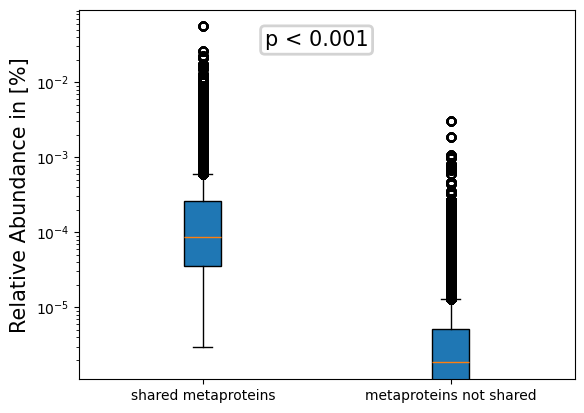

In [72]:
# Plotting average abundance in logarithmic scale
fig, ax = plt.subplots()
ax.set_ylabel('Relative Abundance in [%]', fontsize=15)
box_positions=[1, 2]
new_pathway_group_abundances = [avg_shared*100, avg_not_shared*100]

bplot = ax.boxplot(new_pathway_group_abundances, positions=box_positions,
                   patch_artist=True,  # fill with color
                  )
ax.set_yscale('log')

ax.set_xticklabels(["shared metaproteins", "metaproteins not shared"]) #lables


sig = get_significance_asterisks(mannwhitneyu(avg_shared, avg_not_shared, method="asymptotic").pvalue)
ax.text(
    1.25, max(new_pathway_group_abundances[1])*10,                     # (x, y)-Position im Plot
    f"{sig}",         # Inhalt der Box
    fontsize=15,
    color='black',
    bbox=dict(
        facecolor='white',  # Hintergrundfarbe
        edgecolor='lightgrey',       # Rahmenfarbe
        boxstyle='round,pad=0.2', # Box-Stil
        linewidth=2
    )
)

#plt.title("Average abundance of metaproteins (shared / not shared between discovery cohorts")
plt.savefig("SupplementaryFigure2.png")
plt.show()